In [1]:
# step 1 import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# step 2 load dataset

data = pd.read_csv("data/house_data.csv")
data.columns = data.columns.str.strip()
data.head()

,House Size,Bedrooms,Bathrooms,Age,Distance from City,Price
0,500,1,1,10,12,25
1,800,2,1,8,10,40
2,1000,2,2,6,8,50
3,1200,3,2,4,5,65
4,1500,3,3,2,3,90


In [5]:
# step 3 select input columns and output column

X = data[['House Size', 
          'Bedrooms', 
          'Bathrooms', 
          'Age', 
          'Distance from City']]

y = data['Price']

In [6]:
# step 4 split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

In [7]:
# step 5 train linear regression model

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# step 6 get coefficients and intercept

intercept = model.intercept_
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

intercept, coefficients

(np.float64(53.03212708416973),
               Feature  Coefficient
 0          House Size     0.021969
 1            Bedrooms     1.136334
 2           Bathrooms    -0.757483
 3                 Age    -0.757702
 4  Distance from City    -2.651518)

In [9]:
# step 7 predict test results

y_pred = model.predict(X_test)

In [10]:
# step 8 compare actual and predicted prices

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

results

,Actual Price,Predicted Price
0,40,39.545335
1,90,77.651518


In [11]:
# step 9 evaluate model performance

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(76.34585818363335, 0.8778466269061866)

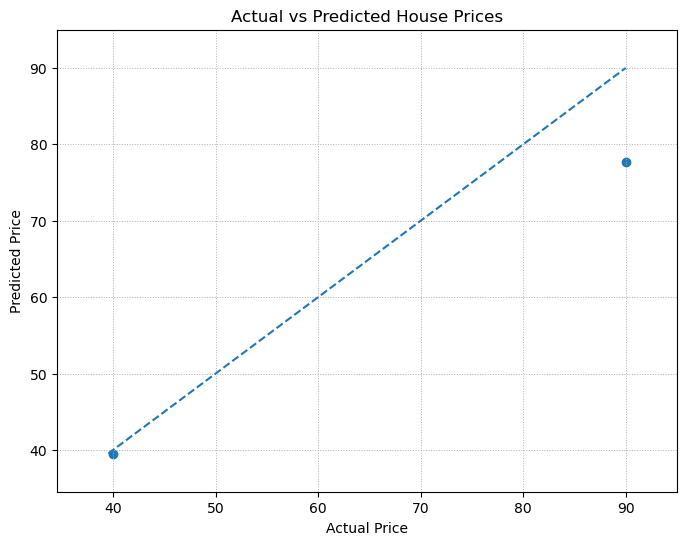

In [15]:
# step 10 visualize improved actual vs predicted

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot([min_val, max_val], 
         [min_val, max_val], 
         linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True, linestyle=':', linewidth=0.7)

plt.xlim(min_val - 5, max_val + 5)
plt.ylim(min_val - 5, max_val + 5)

plt.savefig("linear_regression_results.png", dpi=300, bbox_inches="tight")
plt.show()